In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.cluster import KMeans

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#import du fichier avec les données complètes (pays+variables)

data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Donnees_plus.csv',decimal=".", index_col="Zone")
data.head()

,Unnamed: 0,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles
Zone,,,,,,,,,,,
Afghanistan,0,5.0,254.0,-103.185185,78.88,1185.84,5489.888,-2.48,2.27,-1.27,0.00
Albania,1,85.0,438.0,38.000000,-7.88,421.64,1461.321,0.18,3.96,0.17,0.06
Algeria,2,22.0,4858.0,2.000000,36.04,0.00,1158.292,-0.58,3.30,-0.95,0.01
Angola,3,35.0,5873.0,277.000000,87.92,5998.46,6363.600,-0.34,4.42,-0.76,0.00
Argentina,4,182.0,16332.0,-199.000000,20.32,68.22,10921.860,-0.13,-1.72,-0.48,3.43


In [4]:
# supprimer la colonne
data = data.drop('Unnamed: 0', axis=1)

In [5]:
data.head()

,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles
Zone,,,,,,,,,,
Afghanistan,5.0,254.0,-103.185185,78.88,1185.84,5489.888,-2.48,2.27,-1.27,0.00
Albania,85.0,438.0,38.000000,-7.88,421.64,1461.321,0.18,3.96,0.17,0.06
Algeria,22.0,4858.0,2.000000,36.04,0.00,1158.292,-0.58,3.30,-0.95,0.01
Angola,35.0,5873.0,277.000000,87.92,5998.46,6363.600,-0.34,4.42,-0.76,0.00
Argentina,182.0,16332.0,-199.000000,20.32,68.22,10921.860,-0.13,-1.72,-0.48,3.43


In [6]:
#Enregistrement des pays dans une varibale
pays = data.index
pays

Index(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas',
       ...
       'United Kingdom of Great Britain and Northern Ireland',
       'United Republic of Tanzania', 'United States of America', 'Uruguay',
       'Uzbekistan', 'Vanuatu', 'Venezuela (Bolivarian Republic of)',
       'Viet Nam', 'Zambia', 'Zimbabwe'],
      dtype='object', name='Zone', length=153)

In [7]:
cols=["Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour)","Quantité Aliments_disponible Poules(Milliers tonnes)","Export_Utile(Milliers tonnes)","Taux de croissance_population [%]","Emploi dans la production_vegetale_animale (1000No)",
     "Distance_Economique Pays_France(Km)","Indice Stabilite Politique","Croissance du PIB % annuel","Qualité Reglementaire [-2,5..+2,5]","[%]surfaces agricoles biologiques/total des terres agricoles"]

In [8]:
df_clustering = data[cols]

In [9]:
#Sépartion de nos données. D'un coté X la matrice des données :

X = data.values
X[:5]

array([[ 5.00000000e+00,  2.54000000e+02, -1.03185185e+02,
         7.88800000e+01,  1.18584000e+03,  5.48988800e+03,
        -2.48000000e+00,  2.27000000e+00, -1.27000000e+00,
         0.00000000e+00],
       [ 8.50000000e+01,  4.38000000e+02,  3.80000000e+01,
        -7.88000000e+00,  4.21640000e+02,  1.46132100e+03,
         1.80000000e-01,  3.96000000e+00,  1.70000000e-01,
         6.00000000e-02],
       [ 2.20000000e+01,  4.85800000e+03,  2.00000000e+00,
         3.60400000e+01,  0.00000000e+00,  1.15829200e+03,
        -5.80000000e-01,  3.30000000e+00, -9.50000000e-01,
         1.00000000e-02],
       [ 3.50000000e+01,  5.87300000e+03,  2.77000000e+02,
         8.79200000e+01,  5.99846000e+03,  6.36360000e+03,
        -3.40000000e-01,  4.42000000e+00, -7.60000000e-01,
         0.00000000e+00],
       [ 1.82000000e+02,  1.63320000e+04, -1.99000000e+02,
         2.03200000e+01,  6.82200000e+01,  1.09218600e+04,
        -1.30000000e-01, -1.72000000e+00, -4.80000000e-01,
         3.

In [10]:
#Scaling (Mise à l'échelle)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

In [11]:
##On espère avoir une moyenne à 0 et un écart type à 1
pd.DataFrame(X_scaled).describe().round(2).iloc[1:3:, : ]

,0,1,2,3,4,5,6,7,8,9
mean,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


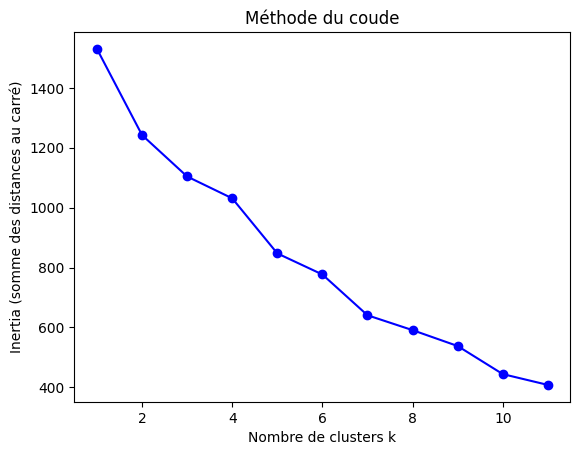

In [12]:
#Utiliser la méthode du coude (elbow method) pour choisir k

inertia = []
K_range = range(1, 12)
for k in K_range:
  # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    # On entraine
    kmeans.fit(X_scaled)
    # On enregistre l'inertie obtenue :
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertia (somme des distances au carré)')
plt.title('Méthode du coude')

#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Clustering_Kmeans_plus.png", dpi=300, bbox_inches="tight")

plt.show()

Analyse de la courbe :Entre k = 1 et k = 4, l’inertie baisse très fortement, puis la pente se réduit nettement à partir de k ≈ 5 ce qui correspond exactement à la définition du « coude » (changement de pente marqué sur la courbe inertie vs k) Au‑delà de k = 6–7, la courbe devient presque linéaire. On choisit k=5 (niveau de la cassure)

In [13]:
#:Appliquer Kmeans

k = 5  # choisi après la méthode du coude
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
data['cluster'] = clusters
print(data)

                                    Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour)  \
Zone                                                                                                       
Afghanistan                                                                       5.0                      
Albania                                                                          85.0                      
Algeria                                                                          22.0                      
Angola                                                                           35.0                      
Argentina                                                                       182.0                      
...                                                                               ...                      
Vanuatu                                                                          40.0                      
Venezuela (Bolivarian Republ

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
#Clustering
#Nous allons calculer les distances en spécifiant la méthode à utiliser:

Z = linkage(X_scaled, method="ward")
Z[:10]

array([[ 92.        , 102.        ,   0.33523072,   2.        ],
       [ 43.        ,  78.        ,   0.35414222,   2.        ],
       [ 11.        ,  53.        ,   0.42080345,   2.        ],
       [132.        , 133.        ,   0.53091531,   2.        ],
       [ 55.        ,  88.        ,   0.5387278 ,   2.        ],
       [ 54.        ,  58.        ,   0.60868647,   2.        ],
       [ 15.        , 121.        ,   0.61732367,   2.        ],
       [  1.        ,  20.        ,   0.66708429,   2.        ],
       [ 79.        , 123.        ,   0.66831082,   2.        ],
       [ 91.        ,  96.        ,   0.72758108,   2.        ]])

In [15]:
#Clusters
k=5

clusters = fcluster(Z, k, criterion='maxclust')
clusters


array([4, 4, 4, 4, 3, 4, 3, 1, 4, 3, 4, 3, 4, 1, 3, 4, 3, 4, 3, 2, 4, 4,
       4, 4, 3, 4, 3, 2, 3, 4, 3, 1, 3, 3, 1, 4, 1, 3, 3, 3, 4, 3, 1, 4,
       4, 4, 1, 1, 4, 4, 1, 4, 1, 3, 3, 4, 4, 4, 3, 1, 1, 5, 4, 4, 4, 1,
       3, 1, 3, 3, 4, 4, 4, 3, 4, 4, 1, 4, 4, 4, 1, 1, 4, 4, 3, 4, 4, 4,
       4, 3, 3, 4, 4, 4, 4, 4, 4, 4, 3, 3, 4, 4, 4, 1, 3, 4, 3, 4, 4, 4,
       1, 1, 3, 4, 1, 4, 4, 3, 3, 1, 3, 4, 4, 4, 4, 1, 4, 3, 1, 4, 4, 3,
       1, 1, 4, 4, 4, 4, 4, 4, 4, 4, 3, 1, 4, 2, 1, 4, 4, 4, 4, 4, 4],
      dtype=int32)

In [16]:
clusters.shape

(153,)

In [18]:
df = pd.DataFrame({"pays" : pays,"cluster" : clusters})
df.head()

,pays,cluster
0,Afghanistan,4
1,Albania,4
2,Algeria,4
3,Angola,4
4,Argentina,3


In [19]:
#Affichade des  5 clusters

for i in range(1, 6) :
    # on fait une selection
    sub_df = df.loc[df.cluster == i]

    # le cluster en question
    print(f"cluster : {i}")

    # on extrait les pays de chaque ligne
    names_list = sub_df.pays.values



    ziped = zip(names_list)
    txt = [f"{n}" for n in ziped]

    # on transforme en str
    txt = " / ".join(txt)

    # on print
    print(txt)
    print("\n\n")


cluster : 1
('Austria',) / ('Belgium',) / ('Croatia',) / ('Czechia',) / ('Denmark',) / ('Estonia',) / ('Finland',) / ('France',) / ('Germany',) / ('Greece',) / ('Hungary',) / ('Iceland',) / ('Ireland',) / ('Italy',) / ('Latvia',) / ('Lithuania',) / ('Luxembourg',) / ('Norway',) / ('Poland',) / ('Portugal',) / ('Romania',) / ('Sao Tome and Principe',) / ('Slovenia',) / ('Spain',) / ('Sweden',) / ('Switzerland',) / ('United Kingdom of Great Britain and Northern Ireland',) / ('Uruguay',)



cluster : 2
('Brazil',) / ('China; mainland',) / ('United States of America',)



cluster : 3
('Argentina',) / ('Australia',) / ('Bahamas',) / ('Barbados',) / ('Belize',) / ('Bolivia (Plurinational State of)',) / ('Botswana',) / ('Canada',) / ('Chile',) / ('Colombia',) / ('Costa Rica',) / ('Cuba',) / ('Cyprus',) / ('Dominica',) / ('Dominican Republic',) / ('Ecuador',) / ('El Salvador',) / ('Grenada',) / ('Guatemala',) / ('Honduras',) / ('Israel',) / ('Japan',) / ('Jordan',) / ('Kuwait',) / ('Malaysia',

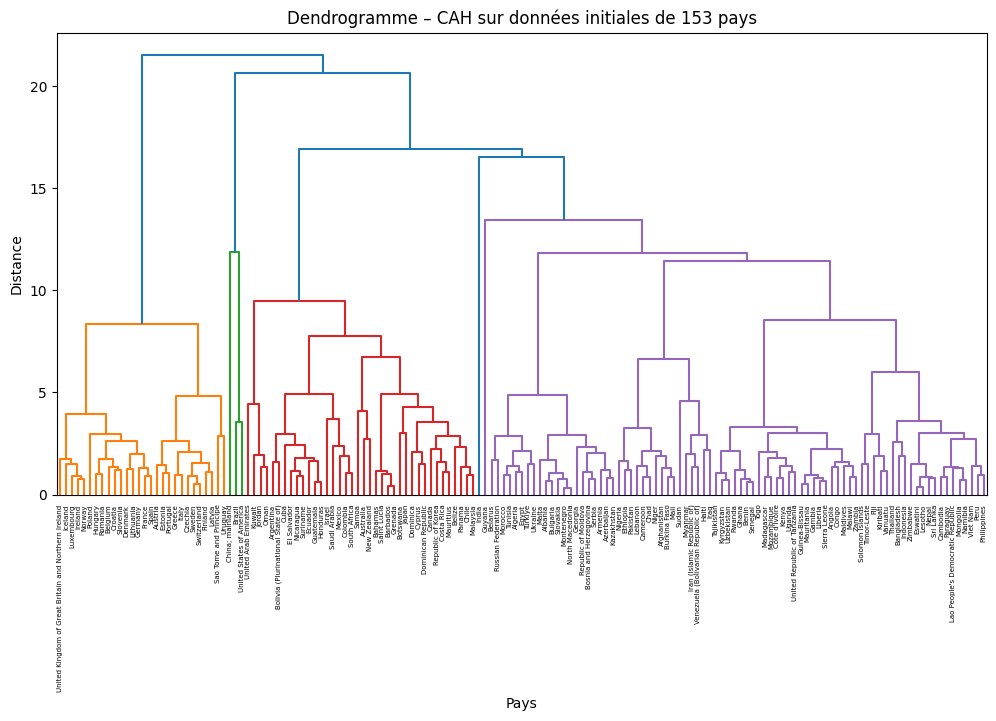

In [20]:
#affichage du dendrogramme
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=df_clustering.index,
    leaf_rotation=90
)
plt.title("Dendrogramme – CAH sur données initiales de 153 pays")
plt.xlabel("Pays")
plt.ylabel("Distance")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Dendrogramme_CAH_donnees_plus.png", dpi=300, bbox_inches="tight")
plt.show()
